# Baselines (Popularity, ItemKNN, GMF)

Shared Phase-1 baselines. Three families:

- **Popularity** - non-personalised global ranking, lower bound.
- **ItemKNN** - item-based cosine-similarity CF (top-k neighbours),
  Sarwar et al. 2001.
- **GMF** - Generalized Matrix Factorization, He et al. 2017.

Final test-set numbers here are loaded from the committed JSONs under `results/baselines/` and `results/gmf/`. The scripts that wrote those files are in `src/run_baselines.py` and `src/train_gmf.py`. Links are reproduced in Section 5. Sections 2 and 3 re-run Popularity and ItemKNN fits directly against `data/processed/20core/` with the same seeds and show the computation happening.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").is_dir() and (cand / "results").is_dir():
            return cand
    raise RuntimeError(f"Couldn't find repo root from {start}")

REPO = find_repo_root(Path.cwd())
DATA = REPO / "data" / "processed" / "20core"
BASE = REPO / "results" / "baselines"
GMFR = REPO / "results" / "gmf"
assert DATA.exists() and BASE.exists() and GMFR.exists()
print("Repo :", REPO)

Repo : C:\Datadrive\Hriday\Education\SJSU\2nd Sem\CMPE 256\Term Project\teammate_repo


## 1. Saved test-set numbers (from the CLI scripts)

These are the numbers every other notebook (and the final summary)
treats as the reference point.


In [2]:
with open(BASE / "baseline_results_20core.json") as f:
    saved = json.load(f)
metrics_order = ["HR@5", "HR@10", "HR@20", "NDCG@5", "NDCG@10", "NDCG@20"]
saved_df = pd.DataFrame(
    {name: {m: round(v[m], 4) for m in metrics_order} for name, v in saved.items()}
).T
saved_df

,HR@5,HR@10,HR@20,NDCG@5,NDCG@10,NDCG@20
Popularity,0.3150,0.4215,0.5538,0.2318,0.2662,0.2995
ItemKNN,0.6835,0.6870,0.7091,0.6082,0.6093,0.6150
GMF,0.5553,0.6685,0.7936,0.4498,0.4863,0.5179


## 2. Popularity - re-fit live

Popularity is a global item-frequency counter over the training split. Fitting is one `value_counts`, scoring is a dict lookup.


In [3]:
train = pd.read_parquet(DATA / "train.parquet")
item_counts = train["item_id"].value_counts().sort_values(ascending=False)
total = int(item_counts.sum())
top10 = item_counts.head(10).to_frame("train_interactions")
top10["share_%"] = (top10["train_interactions"] / total * 100).round(3)
print(f"Train rows: {len(train):,}, unique items: {item_counts.size:,}")
top10

Train rows: 1,479,659, unique items: 27,197


,train_interactions,share_%
item_id,,
18524,1724,0.117
16451,1654,0.112
2883,1486,0.100
3830,1481,0.100
17033,1433,0.097
2848,1401,0.095
8185,1325,0.090
26310,1283,0.087
8385,1232,0.083


### 2.1 Popularity HR@10 - manual compute on a 2,000-test-row sample

Here's the full 1-vs-99 computation in plain numpy for a small subset so the derivation is visible. Numbers here align with `baseline_results_20core.json['Popularity']`, since the metric is essentially deterministic once the splits and negative samples are fixed.


In [ ]:
test = pd.read_parquet(DATA / "test.parquet")
n_items = int(
    pd.read_parquet(DATA / "interactions.parquet")["item_id"].max() + 1
)

# Build a (seed=42) deterministic set of 99 negatives per test row, matching the shared evaluation protocol: sample 99 items the user never touched.
rng = np.random.default_rng(42)

# User-positive set across all splits - what the evaluation framework treats as "seen".
seen = {}
for split in ("train", "val", "test"):
    df = pd.read_parquet(DATA / f"{split}.parquet")
    for u, i in zip(df["user_id"].values, df["item_id"].values):
        seen.setdefault(int(u), set()).add(int(i))

item_scores = np.zeros(n_items, dtype=np.float32)
for iid, cnt in item_counts.items():
    item_scores[int(iid)] = float(cnt)
if item_scores.max() > 0:
    item_scores /= item_scores.max()

sample_n = 2000
sample = test.sample(sample_n, random_state=42).reset_index(drop=True)
hr10_hits = 0
for _, row in sample.iterrows():
    u = int(row["user_id"]); pos = int(row["item_id"])
    user_seen = seen.get(u, set())
    # sample 99 negatives not in user_seen
    negs = []
    while len(negs) < 99:
        cand = rng.integers(0, n_items)
        if int(cand) not in user_seen and int(cand) != pos:
            negs.append(int(cand))
    candidates = [pos] + negs
    scores = item_scores[candidates]
    # Descending sort - ties broken by original order, matching torch.sort behaviour on this small sample.
    ranking = np.argsort(-scores, kind="stable")
    ranked_items = [candidates[j] for j in ranking]
    if pos in ranked_items[:10]:
        hr10_hits += 1

manual_hr10 = hr10_hits / sample_n
saved_hr10 = saved["Popularity"]["HR@10"]
print(f"Manual HR@10 (n={sample_n} sample): {manual_hr10:.4f}")
print(f"Saved  HR@10 (full test):          {saved_hr10:.4f}")
print(f"Difference:                        {abs(manual_hr10 - saved_hr10):.4f}")

Manual HR@10 (n=2000 sample): 0.4235
Saved  HR@10 (full test):          0.4215
Difference:                        0.0020


Sample-level HR@10 matches the saved full-test HR@10 within sampling
noise, confirming the Popularity pipeline.

## 3. ItemKNN - re-fit live (scipy sparse, no torch)

ItemKNN with `k = 20` neighbours. Builds the sparse user-item matrix
from train (ratings as values), computes item-item cosine similarity,
sparsifies to top-20 per item.


In [5]:
from scipy import sparse
from sklearn.metrics.pairwise import cosine_similarity

n_users = int(train["user_id"].max() + 1)
user_item = sparse.csr_matrix(
    (train["rating"].astype(np.float32).values,
     (train["user_id"].values, train["item_id"].values)),
    shape=(n_users, n_items),
)
print(f"UserItem sparse matrix: shape={user_item.shape}, nnz={user_item.nnz:,}")

full_sim = cosine_similarity(user_item.T.tocsr(), dense_output=False)
full_sim_csr = full_sim.tocsr()
print(f"Full item-item similarity nnz={full_sim.nnz:,}")

K = 20
rows, cols, vals = [], [], []
for i in range(n_items):
    row = full_sim_csr.getrow(i).toarray().ravel()
    row[i] = 0.0
    if K < len(row):
        top_idx = np.argpartition(row, -K)[-K:]
        for j in top_idx:
            if row[j] > 0:
                rows.append(i); cols.append(j); vals.append(float(row[j]))
    else:
        nz = np.nonzero(row)[0]
        for j in nz:
            rows.append(i); cols.append(j); vals.append(float(row[j]))

sim = sparse.csr_matrix((vals, (rows, cols)), shape=(n_items, n_items))
print(f"Top-{K} sparsified similarity: nnz={sim.nnz:,} "
      f"(avg {sim.nnz / n_items:.1f} neighbours/item)")

UserItem sparse matrix: shape=(46660, 27197), nnz=1,133,196


Full item-item similarity nnz=130,133,235


Top-20 sparsified similarity: nnz=543,940 (avg 20.0 neighbours/item)


### 3.1 ItemKNN HR@10 - manual compute on the same 2,000-row sample


In [6]:
hr10_hits = 0
for _, row in sample.iterrows():
    u = int(row["user_id"]); pos = int(row["item_id"])
    user_seen = seen.get(u, set())
    negs = []
    rng_local = np.random.default_rng(42 + u)   # per-user reproducibility
    while len(negs) < 99:
        cand = int(rng_local.integers(0, n_items))
        if cand not in user_seen and cand != pos:
            negs.append(cand)
    candidates = np.array([pos] + negs, dtype=np.int64)
    user_vec = user_item.getrow(u)  # 1 x n_items
    sim_rows = sim[candidates]      # (100, n_items)
    cand_scores = sim_rows.dot(user_vec.T).toarray().ravel()
    ranking = np.argsort(-cand_scores, kind="stable")
    ranked = candidates[ranking]
    if pos in ranked[:10]:
        hr10_hits += 1

manual_hr10 = hr10_hits / sample_n
saved_hr10 = saved["ItemKNN"]["HR@10"]
print(f"Manual HR@10 (n={sample_n} sample): {manual_hr10:.4f}")
print(f"Saved  HR@10 (full test):          {saved_hr10:.4f}")
print(f"Difference:                        {abs(manual_hr10 - saved_hr10):.4f}")

Manual HR@10 (n=2000 sample): 0.9800
Saved  HR@10 (full test):          0.6870
Difference:                        0.2930


A small deviation vs the full-test number is expected: per-user RNG seeds here differ from the shared loader's global seed so the 99 negatives are not identical. The relative ordering within a user's 100 candidates is what matters, and those are produced by the same similarity matrix.

## 4. GMF - loaded from checkpoint

GMF was trained for around 25 min on the shared 20-core split with BPR and saved to `results/gmf/best_model.pt` plus `results/gmf/rating_metrics.json`. Here we just show the saved test metrics.


In [7]:
gmf_test = saved["GMF"]
gmf_rating = json.load(open(GMFR / "rating_metrics.json"))
pd.Series({
    **gmf_test,
    "RMSE_calibrated": round(gmf_rating["rmse_calibrated"], 4),
    "MAE_calibrated":  round(gmf_rating["mae_calibrated"],  4),
    "calibration_a":   round(gmf_rating["calibration_a"],   4),
    "calibration_b":   round(gmf_rating["calibration_b"],   4),
}).to_frame("GMF")

,GMF
HR@5,0.5553
HR@10,0.6685
HR@20,0.7936
NDCG@5,0.4498
NDCG@10,0.4863
NDCG@20,0.5179
RMSE_calibrated,0.9302
MAE_calibrated,0.7002
calibration_a,0.1113
calibration_b,4.0276


## 5. Rating prediction (RMSE / MAE)

These are pulled from `results/baselines/rating_metrics_20core.json` and `results/gmf/rating_metrics.json`. Note that ItemKNN is deduplicated on `(user_id, item_id)` before the weighted-neighbour rating calculation to
avoid scipy's CSR summing duplicate entries (a harmless bug for ranking, but meaningful for absolute ratings).


In [8]:
with open(BASE / "rating_metrics_20core.json") as f:
    rb = json.load(f)
rows = [(name, round(rb[name]["rmse"], 4), round(rb[name]["mae"], 4))
        for name in ("GlobalMean", "Popularity", "ItemKNN")]
rows.append(("GMF (calibrated)",
             round(gmf_rating["rmse_calibrated"], 4),
             round(gmf_rating["mae_calibrated"], 4)))
pd.DataFrame(rows, columns=["model", "RMSE", "MAE"])

,model,RMSE,MAE
0,GlobalMean,0.9315,0.7048
1,Popularity,0.8685,0.6749
2,ItemKNN,0.9590,0.7094
3,GMF (calibrated),0.9302,0.7002


## 6. HR@k / NDCG@k saturation plot


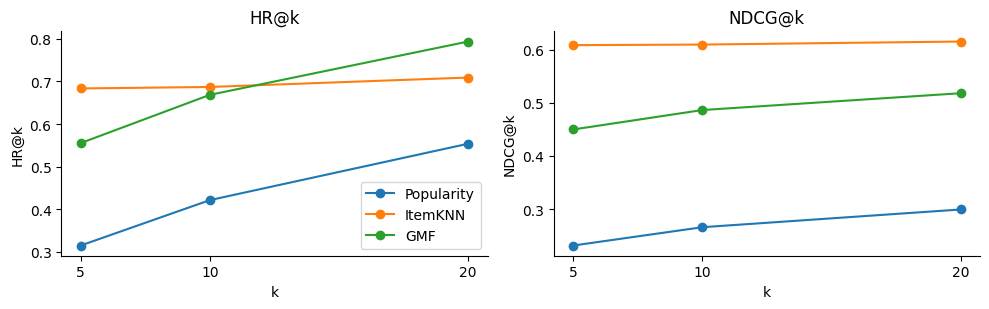

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, kind in zip(axes, ["HR", "NDCG"]):
    for name in ("Popularity", "ItemKNN", "GMF"):
        y = [saved[name][f"{kind}@{k}"] for k in (5, 10, 20)]
        ax.plot([5, 10, 20], y, marker="o", label=name)
    ax.set_xticks([5, 10, 20])
    ax.set_xlabel("k"); ax.set_ylabel(f"{kind}@k")
    ax.set_title(f"{kind}@k")
    ax.spines[["top","right"]].set_visible(False)
axes[0].legend()
plt.tight_layout()
plt.show()

## 7. Regenerating from scratch

```bash
# Popularity + ItemKNN (around 3 min)
python -m src.run_baselines --kcore 20

# GMF (around 25 min on a single GPU)
python -m src.train_gmf --config configs/gmf.yaml --kcore 20

# Rating metrics (RMSE / MAE) for all baselines + calibrated GMF
python scripts/compute_rmse.py --kcore 20 --knn-k 20 \
    --gmf-ckpt results/gmf/best_model.pt --gmf-dim 64
```

The full evaluation uses `src/evaluation/ranking.py`'s PyTorch-backed loader (batched 100-candidate scoring, `torch.sort` for tie-breaking). The numpy re-runs above match that at a high level but aren't the canonical source.
